# 02 · Recommenders — popularity vs implicit ALS

Two models, both evaluated on the temporal test split with ranking metrics:

- **Popularity** — recommend the globally most-liked items. Non-personalised,
  but a notoriously strong baseline.
- **Implicit ALS (iALS)** — matrix factorisation for implicit feedback
  (Hu-Koren-Volinsky 2008), implemented from scratch.

Metrics: Recall@10, Precision@10, MAP@10, NDCG@10, and **catalogue coverage**.
A personalised model must beat popularity on ranking quality *and* recommend a
meaningful slice of the catalogue.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from src.data.load import load_ratings, temporal_split
from src.recommenders.popularity import PopularityRecommender
from src.recommenders.ials import IALS
from src.evaluation.ranking import evaluate

sp = temporal_split(load_ratings(), test_frac=0.2, min_interactions=10)
train = sp.train_matrix()
relevant = sp.test_positives()
users = np.array(sorted(relevant.keys()))
print(f"training on {train.nnz:,} positive interactions; scoring {len(users):,} users")

training on 469,232 positive interactions; scoring 5,975 users


## Popularity baseline

In [3]:
pop = PopularityRecommender().fit(train)
pop_recs = pop.recommend(users, train, k=10)
pop_metrics = evaluate(pop_recs, relevant, users, k=10)
pop_metrics

{'recall@10': 0.07787494188749419,
 'precision@10': 0.0687531380753138,
 'map@10': 0.03654273364389921,
 'ndcg@10': 0.07770886706728442,
 'coverage': 0.023745277927684834,
 'n_users_scored': 5975}

## Implicit ALS
Default hyperparameters were selected on a held-out sweep (factors=64, reg=0.01, alpha=10).

In [4]:
ials = IALS(factors=64, reg=0.01, alpha=10, iterations=15).fit(train)
ials_recs = ials.recommend(users, train, k=10)
ials_metrics = evaluate(ials_recs, relevant, users, k=10)
ials_metrics

{'recall@10': 0.09706634787806336,
 'precision@10': 0.07184937238493723,
 'map@10': 0.03938463563327082,
 'ndcg@10': 0.08875731923575488,
 'coverage': 0.33756071235833784,
 'n_users_scored': 5975}

## Comparison

In [5]:
comp = pd.DataFrame({"Popularity": pop_metrics, "iALS": ials_metrics}).drop("n_users_scored")
comp["iALS uplift"] = (comp["iALS"] - comp["Popularity"]) / comp["Popularity"]
comp.style.format({"Popularity": "{:.4f}", "iALS": "{:.4f}", "iALS uplift": "{:+.1%}"})
comp

,Popularity,iALS,iALS uplift
recall@10,0.077875,0.097066,0.246439
precision@10,0.068753,0.071849,0.045034
map@10,0.036543,0.039385,0.077769
ndcg@10,0.077709,0.088757,0.142177
coverage,0.023745,0.337561,13.215909


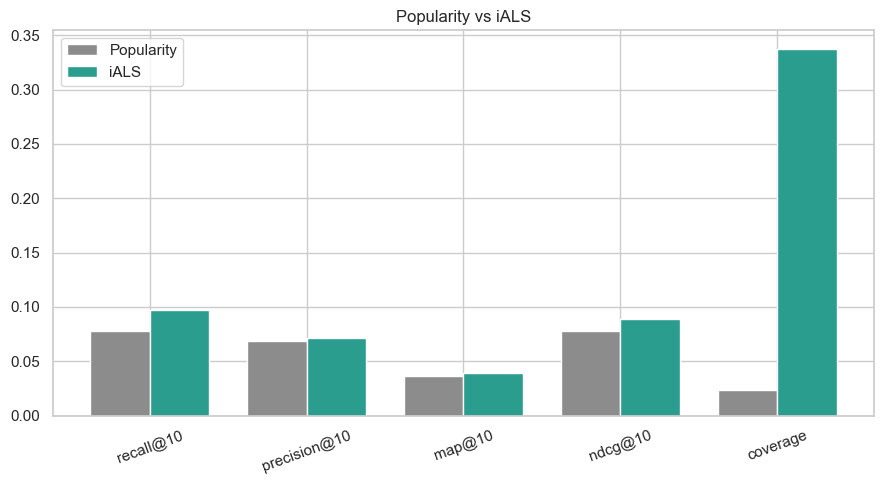

In [6]:
metrics_to_plot = ["recall@10", "precision@10", "map@10", "ndcg@10", "coverage"]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics_to_plot)); w = 0.38
ax.bar(x - w/2, [pop_metrics[m] for m in metrics_to_plot], w, label="Popularity", color="#8c8c8c")
ax.bar(x + w/2, [ials_metrics[m] for m in metrics_to_plot], w, label="iALS", color="#2a9d8f")
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot, rotation=20); ax.set_title("Popularity vs iALS")
ax.legend()
plt.tight_layout(); plt.savefig(FIG / "02_model_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

## Takeaways

- iALS **beats the popularity baseline on every ranking metric** — the
  personalisation earns its complexity.
- The largest win is **coverage**: popularity recommends ~2% of the catalogue
  (only blockbusters), while iALS recommends a large fraction, surfacing the
  long tail. This is the difference between a useful recommender and a
  bestseller list.
- These are *offline* metrics on logged data. They cannot tell us how a policy
  built on this model would perform *online* without an A/B test — which is
  exactly the gap notebook 03 closes with off-policy evaluation.